In [6]:
remotes::install_github('kaskr/adcomp/TMB')

Using github PAT from envvar GITHUB_PAT

Skipping install of 'TMB' from a github remote, the SHA1 (b30e7e1f) has not changed since last install.
  Use `force = TRUE` to force installation



In [130]:
here::i_am('code/model.ipynb')
library(dplyr)
library(tidyr)
library(expm)
library(here)
library(TMB)
library(ggplot2)
devtools::load_all('~/Code/R/ktools')

here() starts at /Users/knguyen/Library/CloudStorage/Dropbox/MultistageSurv

i Loading ktools
i Re-compiling ktools (debug build)



-- R CMD INSTALL ---------------------------------------------------------------
* installing *source* package 'ktools' ...
** using staged installation
** libs
Warnung: kein Quellkode gefunden
* DONE (ktools)


In [131]:
options(
    ggplot2.discrete.colour=ktools:::okabe,
    ggplot2.discrete.fill=ktools:::okabe
)

okcol = c(
    base03 = "#002d38",
    base02 = "#093946",
    base01 = "#5b7279",
    base00 = "#657377",
    base0 = "#98a8a8",
    base1 = "#8faaab",
    base2 = "#f1e9d2",
    base3 = "#fbf7ef",
    yellow = "#ac8300",
    orange = "#d56500",
    red = "#f23749",
    magenta = "#dd459d",
    violet = "#7d80d1",
    blue = "#2b90d8",
    cyan = "#259d94",
    green = "#819500")

library('showtext')
font_add_google('Roboto Slab', 'Roboto Slab')
showtext_auto()

k.theme <- theme_light() +
    theme(
        panel.grid = element_blank(),
        panel.background = element_rect(fill = okcol['base3']),
        # panel.grid.minor = element_blank(),
        # panel.grid.major = element_blank(),
        strip.background = element_rect("white"),
        strip.text = element_text(color = "grey20", hjust = 0),
        text = element_text(size = 11, family = 'Roboto Slab')
    )

## Data prep

In [132]:
d <- readRDS(here('data/cleaned.rds'))

In [133]:
d %>% 
filter(stringr::str_detect(lab, '^MW')) %>% count(lab)

lab,n
<chr>,<int>
MW2000DHS,16312
MW2004DHS,14959
MW2010DHS,30195
MW2015DHS,32040


In [11]:
vroom::vroom(here("data/new_d.csv"), col_select = -1, show_col_types = F) %>% 
    mutate(
        cid = as_numeric(cc) - 1, 
        A = case_when(A == 'V' ~ 0, A == "X" ~ 1, A == "M" ~ 2, A == 'S' ~ 3, A == "D" ~ 4, A == "W" ~ 5, A == "R" ~ 6),
        Z = case_when(Z == 'V' ~ 0, Z == "X" ~ 1, Z == "M" ~ 2, Z == 'S' ~ 3, Z == "D" ~ 4, Z == "W" ~ 5, Z == "R" ~ 6),
        across(where(is.numeric), as.integer)
        ) %>% 
    allot(d)
head(d)

New names:
* `` -> `...1`


cc,sex,A,Z,start,end,n,cid
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
AO,female,2,4,12,50,1,0
AO,female,2,4,13,40,1,0
AO,female,2,4,14,20,1,0
AO,female,2,4,14,41,1,0
AO,female,2,4,15,18,1,0
AO,female,2,4,15,24,2,0


## Likelihood

Log-likelihood of the following cases, assume age at first sex, age at marriage is exact transition time since there will be no intermediate states in between.

- Never had sex $0\rightarrow 0$: 

    $$\text{years from "now"}\times Q_{00}\rvert_{\text{age when entering virgin}}$$

    $$= \text{age}\times Q_{00}\rvert_{age = 0}$$

- Debuting $0\rightarrow 1$:

    $$\text{afs}\times Q_{00}\rvert_{age = 0} + \log Q_{01}\rvert_{age = afs}$$

- Married without debuting $0\rightarrow 2$:

    $$\text{aam}\times Q_{00}\rvert_{age = 0} + \log Q_{02}\rvert_{age = aam}$$

- Married after debuting $1\rightarrow 2$:

    $$\text{(aam - afs)}\times Q_{11}\rvert_{age = afs} + \log Q_{12}\rvert_{age=aam}$$
    
    meaning remaining $aam - afs$ year without marrying someone, then married with a rate $Q_{12}$ which dependent on age.

- Debut and remained debuted $1\rightarrow 1$:

    $$\text{(age - afs)}\times Q_{11}\rvert_{age = afs}$$
    
- Married and stay married till now, never had a dissolution $2\rightarrow 2$:

    $$\text{(age - aam)}\times Q_{22}\rvert_{age = aam}$$

- Married and currently unmarried, unknown when or what happened in betweeen, can be once or more than once married $2\rightarrow 3$:

    $$\text{(age - aam)}\times P_{2x}\rvert_{age = aam}$$

### Model init

Initial parameters and prior

In [34]:
data <- list()
data$prior_base <- c(0, 1) # log normal mean and sd
data$prior_t <- c(0, 0.01) # mean and sd

N_PAR = 7

init <- list(
    # base line hazard
    intercepts = rnorm(N_PAR, data$prior_base[1], data$prior_base[2]), 
    # proportional hazard by age
    betas = rnorm(N_PAR, data$prior_base[1], data$prior_base[2])
    # no betas for VX, VM
    # betas = rnorm(N_PAR - 2, data$prior_base[1], data$prior_base[2])
)

Need to install TMB from source (`remotes`)

In [40]:
library('TMB')
library('here')
unlink(here('code/modelexact.so'))
ktools::tmb_unload('modelexact')
TMB::compile(here("code/modelexact.cpp"))
base::dyn.load(TMB::dynlib(here("code/modelexact")))
# invisible(TMB::config(tape.parallel = 0, DLL = "model"))
# TMB::openmp(4)

Unload  1 loaded versions.


Note: Using Makevars in /Users/knguyen/.R/Makevars 


using C++ compiler: 'Apple clang version 15.0.0 (clang-1500.0.40.1)'

using SDK: 'MacOSX14.0.sdk'



[1] 0

Fitting country by country

In [41]:
cc <- unique(d$cc)
cc

[1] "AO" "BF" "BJ" "BU" "CD" "CG" "CI" "CM" "ET" "GA" "GH" "GM" "GN" "KE" "KM"
[16] "LB" "LS" "MD" "ML" "MR" "MW" "MZ" "NG" "NI" "NM" "RW" "SL" "SN" "ST" "SZ"
[31] "TD" "TG" "TZ" "UG" "ZA" "ZM" "ZW"

## TEst run one

In [44]:
tdt <- filter(d, cc == 'MW', sex == 'male') %>%
    select(A, Z, start, end, n) %>%
    as.list()
data <- modifyList(data, tdt)
glimpse(data)

List of 7
 $ prior_base: num [1:2] 0 1
 $ prior_t   : num [1:2] 0 0.01
 $ A         : int [1:3306] 2 2 2 2 2 2 2 2 2 2 ...
 $ Z         : int [1:3306] 4 4 4 4 4 4 4 4 4 4 ...
 $ start     : int [1:3306] 13 16 16 16 17 18 18 19 19 20 ...
 $ end       : int [1:3306] 45 20 21 34 21 26 44 22 24 22 ...
 $ n         : int [1:3306] 1 1 1 1 1 1 1 1 1 1 ...


In [45]:
obj <- TMB::MakeADFun(data, init, DLL = "modelexact", silent = TRUE)

In [46]:
fit <- nlminb(obj$par, obj$fn, obj$gr, control = list(trace = 1, maxit = 500))

  0:     1660741.5: -1.87203  1.27559 -0.412550 -1.46878 -0.426151 0.319613 -1.31846 -1.88226 0.176403  1.97147 0.151941 0.515679 -1.58625 0.542462
  1:     803672.25: -1.89742 0.284039 -0.458076 -1.48457 -0.476765 0.263191 -1.31563 -1.88342 0.0900572  1.96205 0.147049 0.499926 -1.60312 0.543108
  2:     434686.48: -2.44180 -0.309275 -1.40625 -1.83366 -1.53121 -0.901936 -1.25244 -1.90719 0.0497049  1.76602 0.0389004 0.172011 -1.95121 0.557547
  3:     232777.53: -2.61723 -2.10541 -0.943512 -2.59684 -1.33868 -0.457525 -1.09367 -1.83940 -0.0672963  1.87647 -0.193921 0.239197 -1.80936 0.593795
  4:     149288.78: -2.87129 -3.32897 -1.92588 -2.79109 -2.10707 -1.48662 -0.998263 -1.81830 -0.156979  1.67676 -0.253858 0.00263237 -2.11344 0.615549
  5:     133761.08: -3.27898 -3.87175 -1.42347 -3.71363 -3.40297 -2.33460 -0.701947 -1.59987 -0.105377  1.82150 -0.538513 -0.393761 -2.35678 0.683558
  6:     127890.76: -3.02247 -4.31950 -3.34738 -3.86520 -3.63491 -2.75395 -0.633819 -1.43308 -0.08646

In [47]:
fit$convergence
fit$message

[1] 0

[1] "relative convergence (4)"

## Post-fit

In [48]:
PQ <- function(pars, t = 1) {
    P <- Q <- matrix(0, 7, 7)
    Q[1, 2] = pars[1]
    Q[1, 3] = pars[2]
    Q[2, 3] = pars[3]
    Q[3, 4:6] = pars[4:6]
    Q[4:6, 7] = pars[6]
    Q[7, 4:6] = pars[7]
    for(i in 1:7) Q[i,i] = -sum(Q[i, ])
    P = expm::expm(Q * t)
    list(P=P, Q=Q)
}

In [49]:
ic <- obj$report()$intercepts
bt <- c(obj$report()$betas)

In [50]:
etas <- exp(cbind(1, age = 0:65/100) %*% rbind(ic, bt))

### Ms family

In [68]:
PQ.list <- apply(etas, 1, PQ, t = 1)

In [73]:
sapply(PQ.list, function(x) {
    c(
    VV = x$P[1,1],
    VX = x$P[1,2],
    VM = x$P[1,3],
    XX = x$P[2,2],
    XM = x$P[2,3],
    MM = x$P[3,3],
    MS = x$P[3,4],
    MD = x$P[3,5],
    MW = x$P[3,6],
    MR = x$P[3,7]
    )
    }
    ) %>% 
    as.data.frame %>% 
    tibble::rownames_to_column()  %>% 
    pivot_longer(-rowname) %>% 
    mutate(age = rep(0:65, 10), name = NULL) %>% 
    rename(name = rowname) %>% 
    allot(M.est)


In [75]:
model.est <- M.est %>% 
    mutate(
        group = case_when(
            stringr::str_detect(name, '^V') ~ 0,
            stringr::str_detect(name, '^X') ~ 1,
            TRUE ~ 2,
        )
    )


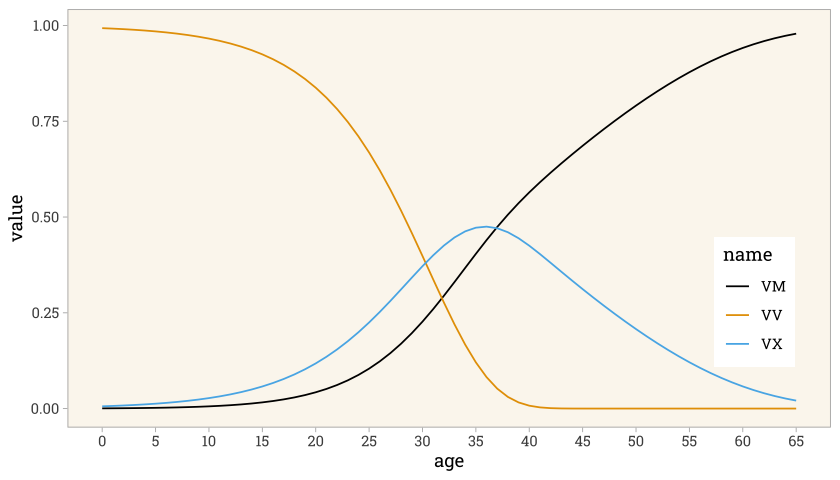

In [111]:
model.est %>% filter(group == 0) %>% 
    ggplot(aes(age, value, color = name)) +
    geom_line() +
    # facet_wrap(~name, scales = 'free') +
    k.theme +
    scale_x_continuous(labels = seq(0, 65, 5), breaks =  seq(0, 65, 5)) +
    theme(legend.position = c(.9, .3))

In [122]:
d %>% filter(cc == 'SN', sex == 'female') %>% 
filter(A == 0)  %>% 
arrange(start)

cc,sex,A,Z,start,end,n,cid
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
SN,female,0,0,0,1,14602,27
SN,female,0,0,0,1,15688,27
SN,female,0,0,0,1,8636,27
SN,female,0,0,0,1,8488,27
SN,female,0,0,0,1,8851,27
SN,female,0,0,0,1,8865,27
SN,female,0,0,0,1,16787,27
SN,female,0,0,0,1,9414,27
SN,female,0,0,0,1,8649,27


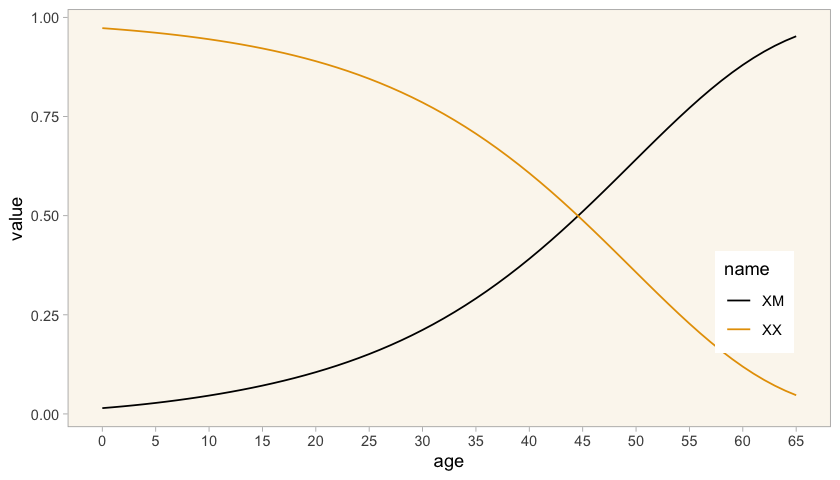

In [ ]:
model.est %>% filter(group == 1) %>% 
    ggplot(aes(age, value, color = name)) +
    geom_line() +
    # facet_wrap(~name, scales = 'free') +
    k.theme +
    scale_x_continuous(labels = seq(0, 65, 5), breaks =  seq(0, 65, 5)) +
    theme(legend.position = c(.9, .3))


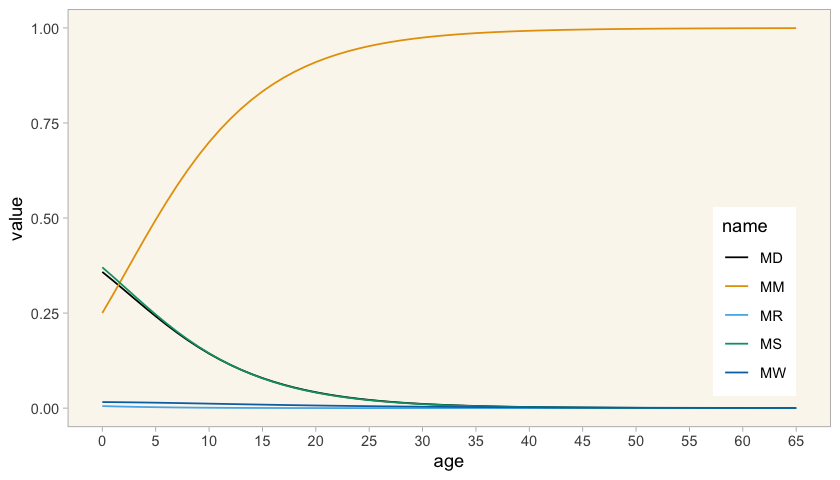

In [78]:
model.est %>% filter(group == 2) %>% 
    ggplot(aes(age, value, color = name)) +
    geom_line() +
    # facet_wrap(~name, scales = 'free') +
    k.theme +
    scale_x_continuous(labels = seq(0, 65, 5), breaks =  seq(0, 65, 5)) +
    theme(legend.position = c(.9, .3))


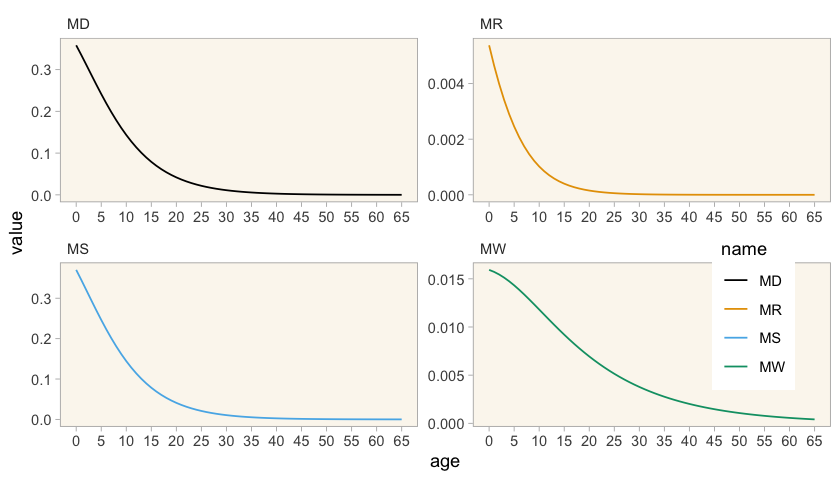

In [80]:
model.est %>% filter(group == 2, name != 'MM') %>% 
    ggplot(aes(age, value, color = name)) +
    geom_line() +
    facet_wrap(~name, scales = 'free') +
    k.theme +
    scale_x_continuous(labels = seq(0, 65, 5), breaks =  seq(0, 65, 5)) +
    theme(legend.position = c(.9, .3))


## run all

In [18]:
unlink(here('fitted'),force = T,recursive = T)

In [19]:
dir.create(here('fitted'), F)

for (k in cc) {
    for (s in char(male, female)) {
        cat(k, s, "\n")
        tdt <- filter(d, cc == k, sex == s) %>%
            select(A, Z, start, end, n) %>%
            as.list()
        data <- modifyList(data, tdt)
        t0 <- Sys.time()
        obj <- TMB::MakeADFun(data, init, DLL = "model", silent = TRUE)
        fit <- nlminb(obj$par, obj$fn, obj$gr, control = list(trace = 0, maxit = 500))
        rp <- obj$report(obj$env$last.par.best)
        save <- modifyList(fit, rp)
        save$runtime <- Sys.time() - t0
        saveRDS(save, here("fitted", paste0(k, s, ".rds")))
    }
}

AO male 
AO female 
BF male 
BF female 
BJ male 
BJ female 
BU male 
BU female 
CD male 
CD female 
CG male 
CG female 
CI male 
CI female 
CM male 
CM female 
ET male 
ET female 
GA male 
GA female 
GH male 
GH female 
GM male 
GM female 
GN male 
GN female 
KE male 
KE female 
KM male 
KM female 
LB male 
LB female 
LS male 
LS female 
MD male 
MD female 
ML male 
ML female 
MR male 
MR female 
MW male 
MW female 
MZ male 
MZ female 
NG male 
NG female 
NI male 
NI female 
NM male 
NM female 
RW male 
RW female 
SL male 
SL female 
SN male 
SN female 
ST male 
ST female 
SZ male 
SZ female 
TD male 
TD female 
TG male 
TG female 
TZ male 
TZ female 
UG male 
UG female 
ZA male 
ZA female 
ZM male 
ZM female 
ZW male 
ZW female 


In [20]:
list.files(here('fitted')) 

[1] "AOfemale.rds" "AOmale.rds"   "BFfemale.rds" "BFmale.rds"   "BJfemale.rds"
 [6] "BJmale.rds"   "BUfemale.rds" "BUmale.rds"   "CDfemale.rds" "CDmale.rds"  
[11] "CGfemale.rds" "CGmale.rds"   "CIfemale.rds" "CImale.rds"   "CMfemale.rds"
[16] "CMmale.rds"   "ETfemale.rds" "ETmale.rds"   "GAfemale.rds" "GAmale.rds"  
[21] "GHfemale.rds" "GHmale.rds"   "GMfemale.rds" "GMmale.rds"   "GNfemale.rds"
[26] "GNmale.rds"   "KEfemale.rds" "KEmale.rds"   "KMfemale.rds" "KMmale.rds"  
[31] "LBfemale.rds" "LBmale.rds"   "LSfemale.rds" "LSmale.rds"   "MDfemale.rds"
[36] "MDmale.rds"   "MLfemale.rds" "MLmale.rds"   "MRfemale.rds" "MRmale.rds"  
[41] "MWfemale.rds" "MWmale.rds"   "MZfemale.rds" "MZmale.rds"   "NGfemale.rds"
[46] "NGmale.rds"   "NIfemale.rds" "NImale.rds"   "NMfemale.rds" "NMmale.rds"  
[51] "RWfemale.rds" "RWmale.rds"   "SLfemale.rds" "SLmale.rds"   "SNfemale.rds"
[56] "SNmale.rds"   "STfemale.rds" "STmale.rds"   "SZfemale.rds" "SZmale.rds"  
[61] "TDfemale.rds" "TDmale.rds"   "TGfemale.rds" "TGmale.rds"   "TZfemale.rds"
[66] "TZmale.rds"   "UGfemale.rds" "UGmale.rds"   "ZAfemale.rds" "ZAmale.rds"  
[71] "ZMfemale.rds" "ZMmale.rds"   "ZWfemale.rds" "ZWmale.rds"

## Post fitting

Extract meta data

In [21]:
iso2 <- list.files(here('fitted')) %>% substr(1, 2)
sex <- list.files(here('fitted')) %>% substr(3, 3)

Intercept and age coefficients

In [30]:
betas <- 
list.files(here('fitted'), full.names = T) %>%
purrr::map_dfr(
    function(x) {
        tmp_ <- readRDS(x)
        sm_age <- tibble(
            sm = tmp_$age_sm, 
            age = rep(0:65, 7), 
            grp = rep(LETTERS[1:7], each = 66)
            )
        es_itc <- tibble(
            itc = tmp_$intercepts, 
            grp = LETTERS[1:7]
            )
        eta_mat <- sm_age %>% 
            left_join(es_itc, 'grp') %>% 
            mutate(eta = exp(itc + sm))  %>% 
            select(age, grp, eta)  %>% 
            pivot_wider(names_from = grp, values_from = eta) 
        eta_mat
    }, 
    .id = 'src'
)

In [32]:
betas %>% mutate(
    src = as.numeric(src),
    iso = iso2[src],
    sex = sex[src]
    )

Convert to P matrix

In [17]:
estP <- map_dfr(seq_along(betas), function(z) {
    eta <- exp(modelmatrix %*% betas[[z]])
    PQages <- napply(1:nrow(eta), function(x) PQ(eta[x, ]))
    map_dfr(PQages, function(x) {
        tibble(
            VV = x$P[1,1],
            VX = x$P[1,2],
            VM = x$P[1,3],
            XX = x$P[2,2],
            XM = x$P[2,3],
            MM = x$P[3,3],
            MS = x$P[3,4],
            MD = x$P[3,5],
            MW = x$P[3,6],
            Re = x$P[4,7],
        )}) %>% 
        mutate(age = 0:65, cc = iso2[z], sex = sex[z])
})

ERROR: Error in map_dfr(seq_along(betas), function(z) {: could not find function "map_dfr"


In [ ]:
estP %>% str()

tibble [4,884 × 13] (S3: tbl_df/tbl/data.frame)
 $ VV : num [1:4884] 0.991 0.989 0.987 0.985 0.983 ...
 $ VX : num [1:4884] 0.00718 0.00835 0.00972 0.01131 0.01315 ...
 $ VM : num [1:4884] 0.00223 0.00262 0.00307 0.0036 0.00422 ...
 $ XX : num [1:4884] 0.927 0.927 0.926 0.925 0.924 ...
 $ XM : num [1:4884] 0.0716 0.0725 0.0734 0.0743 0.0753 ...
 $ MM : num [1:4884] 0.973 0.973 0.974 0.974 0.974 ...
 $ MS : num [1:4884] 0.0231 0.0228 0.0226 0.0223 0.0221 ...
 $ MD : num [1:4884] 0.00111 0.0011 0.00109 0.00107 0.00106 ...
 $ MW : num [1:4884] 0.00256 0.0026 0.00264 0.00269 0.00273 ...
 $ Re : num [1:4884] 0.00258 0.00262 0.00266 0.00269 0.00273 ...
 $ age: int [1:4884] 0 1 2 3 4 5 6 7 8 9 ...
 $ cc : chr [1:4884] "AO" "AO" "AO" "AO" ...
 $ sex: chr [1:4884] "f" "f" "f" "f" ...


In [ ]:
estP %>%
    filter(!(sex == 'f' & age > 49)) %>% # not in data
    mutate(
        region = countrycode::countrycode(cc, 'dhs', 'un.regionsub.name'),
        cc = countrycode::countrycode(cc, 'dhs', 'country.name'),
        debut = VX, 
        married = (VX * XM) + VM,
        divorce = MD, 
        widowed = MW, 
        separated = MS, 
        remarried = Re, 
    ) %>% 
    allot(estPP)

## Estimated transition

In [ ]:
sizing(7,4)
estPP %>% 
    ggplot(aes(age, VV, color = cc)) + 
    geom_line() + 
    facet_wrap(~sex) +
    ktheme +
    guides(color = 'none') +
    labs(title = "Probability of staying virgin", y = '', linetype = "Transition")

plot without title

In [ ]:
estPP %>% 
    ggplot(aes(age, VX, color = cc)) + 
    geom_line() + 
    facet_wrap(~sex) +
    ktheme +
    guides(color = 'none') +
    labs(title = "Probability of debut | virgin", y = '', linetype = "Transition")

plot without title

In [ ]:
estPP %>% 
    ggplot(aes(age, VM, color = cc)) + 
    geom_line() + 
    facet_wrap(~sex) +
    ktheme +
    guides(color = 'none') +
    labs(title = "Probability of marriage | virgin", y = '', linetype = "Transition")

plot without title

In [ ]:
estPP %>% 
    ggplot(aes(age, XM, color = cc)) + 
    geom_line() + 
    facet_wrap(~sex) +
    ktheme +
    guides(color = 'none') +
    labs(title = "Probability of marriage | debut", y = '', linetype = "Transition")

plot without title

In [ ]:
estPP %>% 
    ggplot(aes(age, MD, color = cc)) + 
    geom_line() + 
    facet_wrap(~sex) +
    ktheme +
    guides(color = 'none') +
    labs(title = "Probability of divorve from married", y = '', linetype = "Transition")

plot without title

In [ ]:
estPP %>% 
    ggplot(aes(age, MW, color = cc)) + 
    geom_line() + 
    facet_wrap(~sex) +
    ktheme +
    guides(color = 'none') +
    labs(title = "Probability of widowed from married", y = '', linetype = "Transition")

plot without title

In [ ]:
estPP %>% 
    ggplot(aes(age, MS, color = cc)) + 
    geom_line() + 
    facet_wrap(~sex) +
    ktheme +
    guides(color = 'none') +
    labs(title = "Probability of separated from coupled", y = '', linetype = "Transition")

plot without title

In [ ]:
str(estPP)

tibble [4,292 × 20] (S3: tbl_df/tbl/data.frame)
 $ VV       : num [1:4292] 0.991 0.989 0.987 0.985 0.983 ...
 $ VX       : num [1:4292] 0.00718 0.00835 0.00972 0.01131 0.01315 ...
 $ VM       : num [1:4292] 0.00223 0.00262 0.00307 0.0036 0.00422 ...
 $ XX       : num [1:4292] 0.927 0.927 0.926 0.925 0.924 ...
 $ XM       : num [1:4292] 0.0716 0.0725 0.0734 0.0743 0.0753 ...
 $ MM       : num [1:4292] 0.973 0.973 0.974 0.974 0.974 ...
 $ MS       : num [1:4292] 0.0231 0.0228 0.0226 0.0223 0.0221 ...
 $ MD       : num [1:4292] 0.00111 0.0011 0.00109 0.00107 0.00106 ...
 $ MW       : num [1:4292] 0.00256 0.0026 0.00264 0.00269 0.00273 ...
 $ Re       : num [1:4292] 0.00258 0.00262 0.00266 0.00269 0.00273 ...
 $ age      : int [1:4292] 0 1 2 3 4 5 6 7 8 9 ...
 $ cc       : chr [1:4292] "Angola" "Angola" "Angola" "Angola" ...
 $ sex      : chr [1:4292] "f" "f" "f" "f" ...
 $ region   : chr [1:4292] "Sub-Saharan Africa" "Sub-Saharan Africa" "Sub-Saharan Africa" "Sub-Saharan Africa" ...
 $ de

In [ ]:
estPP %>% 
    ggplot(aes(age, Re, color = cc)) + 
    geom_line() + 
    facet_wrap(~sex, scales = 'free_y') +
    ktheme +
    guides(color = 'none') +
    labs(title = "Probability of remarried", y = '', linetype = "Transition")

plot without title